# **Stage 1: Data Collection and Preprocessing**
---

**Objective:** This notebook implements the data collection pipeline for our JEPA World Model project. We collect episodes from the CartPole-v1 Gymnasium environment, capturing RGB pixel observations along with actions, rewards, and termination flags.

**Storage Strategy:** To avoid filling local disk space on SageMaker, we use **Amazon S3** for temporary HDF5 files during collection. Files are uploaded to S3 in batches and deleted locally, then downloaded only for final consolidation.

**What we'll do:**
1. Check if dataset already exists (skip collection if yes)
2. Understand the CartPole-v1 environment and its observation space
3. Collect episodes using parallel processing with S3 storage
4. Consolidate individual episode files from S3 into a single HDF5 dataset
5. Visualize and analyze the collected data

**Output:** A consolidated HDF5 dataset containing thousands of CartPole episodes, ready for training our VAE encoder in the next stage.

## **Setup and Imports**
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Import our data collection pipeline
from jepacartpole.data_prep import (
    setup_pygame_headless,
    create_cartpole_env,
    collect_data,
    merge_episode_files,
    check_dataset_exists,
    plot_random_samples,
    plot_episode_sequence,
    plot_dataset_statistics,
    print_dataset_summary
)
from jepacartpole.utils import get_data_dir, get_results_dir
from jepacartpole.storage import S3Manager

# Configure matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

# Set random seed for reproducibility
np.random.seed(42)

print("Setup complete!")

Setup complete!


## **Configuration**
---

Configure S3 bucket and data collection parameters:

In [2]:
# S3 Configuration
S3_BUCKET = 'tcc-jepa-cartpole'
S3_PREFIX = 'tmp/raw_data'

# Data collection parameters
NUM_EPISODES = 500       # Total number of episodes to collect
STEPS_PER_EPISODE = 500  # Fixed length of each episode
ACTION_INTERVAL = 20     # Steps between action changes
BATCH_SIZE = 50          # Episodes to collect before uploading to S3

# Directory paths
RAW_DATA_DIR = get_data_dir('raw')
VAE_DATA_DIR = get_data_dir('vae')
OUTPUT_FILE = VAE_DATA_DIR / 'vae_data.h5'

print(f"Configuration:")
print(f"  S3 Bucket: {S3_BUCKET}")
print(f"  S3 Prefix: {S3_PREFIX}")
print(f"  Episodes: {NUM_EPISODES}")
print(f"  Steps per episode: {STEPS_PER_EPISODE}")
print(f"  Total frames: {NUM_EPISODES * STEPS_PER_EPISODE:,}")
print(f"  Batch size (S3 upload): {BATCH_SIZE} episodes")
print(f"  Output file: {OUTPUT_FILE}")

Configuration:
  S3 Bucket: tcc-jepa-cartpole
  S3 Prefix: tmp/raw_data
  Episodes: 500
  Steps per episode: 500
  Total frames: 250,000
  Batch size (S3 upload): 50 episodes
  Output file: /home/sagemaker-user/jepa_cart_pole/data/vae/vae_data.h5


## **Check for Existing Dataset**
---

Before collecting data, check if the final dataset already exists. If it does, we skip collection to save time and resources.

In [3]:
print("Checking for existing dataset...\n")

dataset_exists = check_dataset_exists(str(OUTPUT_FILE), verbose=True)

if dataset_exists:
    print("\n⏭️  Skipping data collection - dataset already exists!")
    print("   To recollect data, delete the file and rerun this notebook.")
    SKIP_COLLECTION = True
else:
    print("\n▶️  No existing dataset found - will proceed with collection")
    SKIP_COLLECTION = False

Checking for existing dataset...


▶️  No existing dataset found - will proceed with collection


## **1. Understanding the CartPole-v1 Environment**
---

The [CartPole-v1](https://gymnasium.farama.org/environments/classic_control/cart_pole/) environment from Gymnasium provides a classic reinforcement learning problem first described by Barto, Sutton, and Anderson in ["Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem"](https://ieeexplore.ieee.org/document/6313077) (1983).

### **Task Description**
A pole is attached by an un-actuated joint to a cart moving along a frictionless track. The goal is to keep the pole balanced upright by applying forces to the cart.

### **Action Space** (Discrete)
- **0**: Push cart to the left
- **1**: Push cart to the right

### **Reward Structure**
A reward of +1 is given for every step the pole remains upright, including the termination step. Episodes can last up to 500 steps (in CartPole-v1), with a threshold of 475 for considering the problem "solved".

### **Observation Space**
Originally, CartPole provides a 4-dimensional state vector:
- Cart position
- Cart velocity  
- Pole angle
- Pole angular velocity

**For our JEPA world model**, we modify the environment to provide **pixel observations** instead, using the `AddRenderObservation` wrapper. This gives us 400×600 RGB images, which is what a vision-based model would see.

Observation space: Box(0, 255, (400, 600, 3), uint8)
Action space: Discrete(2)

Observation shape: (400, 600, 3)
Observation dtype: uint8
Observation range: [0, 255]


/home/sagemaker-user/jepa_cart_pole/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


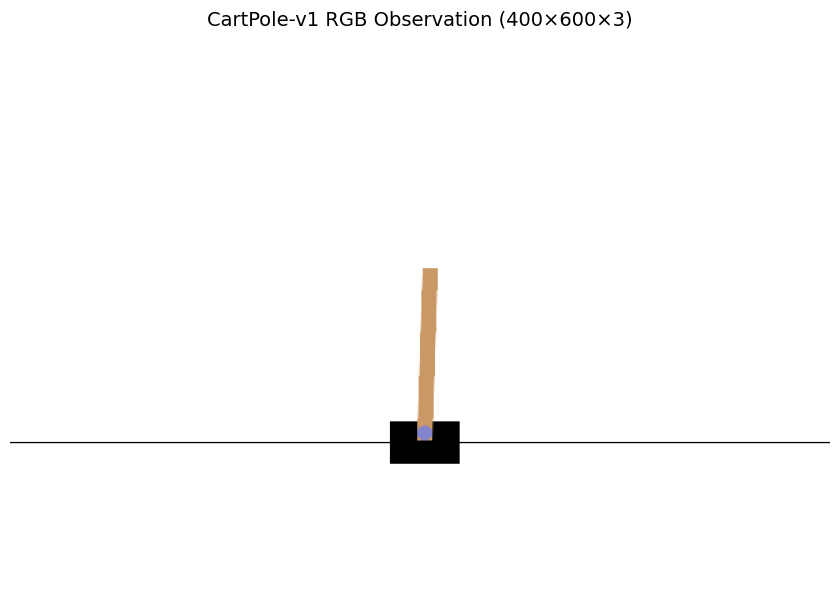

In [4]:
if not SKIP_COLLECTION:
    # Setup pygame for headless rendering
    setup_pygame_headless()

    # Create the environment
    env = create_cartpole_env(grayscale=False)
    print(f"Observation space: {env.observation_space}")
    print(f"Action space: {env.action_space}")

    # Get a sample observation
    obs, _ = env.reset(seed=42)
    print(f"\nObservation shape: {obs.shape}")
    print(f"Observation dtype: {obs.dtype}")
    print(f"Observation range: [{obs.min()}, {obs.max()}]")

    # Visualize the observation
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(obs)
    ax.set_title('CartPole-v1 RGB Observation (400×600×3)', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    env.close()
else:
    print("Skipping environment demo - dataset already exists")

## **2. Parallel Data Collection with S3 Storage**
---

To efficiently collect a large dataset without filling local disk, we use:

### **Collection Strategy**

1. **Parallelization**: Distribute workload across all available CPU cores

2. **Batch Upload to S3**: 
   - Collect a batch of episodes locally (e.g., 50 episodes)
   - Upload batch to S3 immediately
   - Delete local files to free disk space
   - Repeat for next batch

3. **Episode Generation**: Each episode runs for a fixed number of steps (500). If the pole falls before completion, the environment automatically resets and continues.

4. **Action Policy**: Random action policy that changes every 20 steps, creating diverse trajectories.

5. **Smart Caching**: If HDF5 files already exist in S3, skip collection and go directly to consolidation.

### **Storage Benefits**

- **Local disk usage**: Only ~50 episodes at a time (~2-3 GB)
- **S3 storage**: All 500 episodes (~25 GB) stored safely
- **Cost effective**: S3 storage is cheap compared to SageMaker instance disk
- **Temporary files**: Automatically cleaned up after consolidation

In [5]:
if not SKIP_COLLECTION:
    # Check if files already exist in S3
    print("Checking S3 for existing episode files...\n")
    
    s3_manager = S3Manager(S3_BUCKET, verbose=True)
    existing_s3_files = s3_manager.list_files(S3_PREFIX)
    
    if existing_s3_files:
        print(f"\n⏭️  Found {len(existing_s3_files)} episode files in S3")
        print(f"   s3://{S3_BUCKET}/{S3_PREFIX}")
        print(f"   Skipping collection - will use existing S3 files for consolidation")
        SKIP_COLLECTION = True
    else:
        print(f"\n▶️  No existing files in S3 - will proceed with collection")
else:
    print("Skipping S3 check - dataset already exists")

Checking S3 for existing episode files...




⏭️  Found 500 episode files in S3
   s3://tcc-jepa-cartpole/tmp/raw_data
   Skipping collection - will use existing S3 files for consolidation


In [6]:
%%time

if not SKIP_COLLECTION:
    print("Starting parallel data collection with S3 storage...\n")

    result = collect_data(
        num_episodes=NUM_EPISODES,
        max_steps=STEPS_PER_EPISODE,
        output_dir=str(RAW_DATA_DIR),
        action_interval=ACTION_INTERVAL,
        grayscale=False,
        verbose=True,
        use_s3=True,
        s3_bucket=S3_BUCKET,
        s3_prefix=S3_PREFIX,
        batch_size=BATCH_SIZE
    )

    print("\n✅ Data collection completed!")
    print(f"   Files stored in: s3://{S3_BUCKET}/{S3_PREFIX}")
else:
    print("⏭️  Skipping data collection - using existing files")

⏭️  Skipping data collection - using existing files
CPU times: user 50 μs, sys: 19 μs, total: 69 μs
Wall time: 61.8 μs


## **3. Consolidating the Dataset from S3**
---

Now we download the episode files from S3 and merge them into a single consolidated HDF5 dataset.

### **Consolidated Dataset Structure**

```
vae_data.h5
├── images:  uint8   (num_episodes, max_steps, 400, 600, 3)  # RGB observations
├── actions: float32 (num_episodes, max_steps)               # Actions taken
├── rewards: float32 (num_episodes, max_steps)               # Rewards received
└── dones:   bool    (num_episodes, max_steps)               # Episode termination flags
```

The consolidation process:
1. Downloads all episode files from S3 to temporary local directory
2. Verifies data integrity (correct number of steps)
3. Writes to a single HDF5 file with optimized chunking
4. Deletes temporary local files
5. Deletes S3 files to save storage costs

In [7]:
%%time

# Only consolidate if final dataset doesn't exist
if not check_dataset_exists(str(OUTPUT_FILE), verbose=False):
    print("Starting dataset consolidation from S3...\n")

    # Merge episode files from S3
    stats = merge_episode_files(
        episodes_dir=str(RAW_DATA_DIR),
        output_file=str(OUTPUT_FILE),
        max_steps=STEPS_PER_EPISODE,
        delete_temp_files=True,
        verbose=True,
        use_s3=True,
        s3_bucket=S3_BUCKET,
        s3_prefix=S3_PREFIX
    )

    print(f"\n✅ Dataset consolidation completed!")
else:
    print("✅ Final dataset already exists - skipping consolidation")

Starting dataset consolidation from S3...

📥 Found 500 files in S3




📥 Downloading 500 files from S3
   Bucket: tcc-jepa-cartpole
   Prefix: tmp/raw_data
   Destination: /home/sagemaker-user/jepa_cart_pole/data/raw_temp_s3_download



✗ Error downloading tmp/raw_data/worker_0_episode_0.h5: [Errno 28] No space left on device


✗ Error downloading tmp/raw_data/worker_0_episode_1.h5: [Errno 28] No space left on device


✗ Error downloading tmp/raw_data/worker_0_episode_120.h5: [Errno 28] No space left on device


...

✗ Error downloading tmp/raw_data/worker_0_episode_2.h5: [Errno 28] No space left on device


✗ Error downloading tmp/raw_data/worker_0_episode_200.h5: [Errno 28] No space left on device


✗ Error downloading tmp/raw_data/worker_0_episode_201.h5: [Errno 28] No space left on device


CPU times: user 17.5 s, sys: 13.6 s, total: 31.1 s
Wall time: 30.7 s


KeyboardInterrupt: 

## **4. Dataset Analysis and Visualization**
---

Now that we have our consolidated dataset, let's explore and visualize it to ensure data quality and understand its characteristics.

### **4.1 Dataset Summary**

First, let's print a comprehensive summary of the dataset:

In [ ]:
print_dataset_summary(str(OUTPUT_FILE))

### **4.2 Random Sample Visualization**

Let's visualize random frames from across the dataset to see the variety of states captured:

In [ ]:
# Plot random samples
results_dir = get_results_dir('data_prep')
save_path = results_dir / 'random_samples.png'

fig = plot_random_samples(
    h5_path=str(OUTPUT_FILE),
    num_samples=9,
    figsize=(15, 10),
    save_path=str(save_path)
)
plt.show()

### **4.3 Episode Sequence Visualization**

To understand the temporal dynamics, let's visualize a sequence of frames from a single episode:

In [ ]:
# Plot episode sequence
save_path = results_dir / 'episode_sequence.png'

fig = plot_episode_sequence(
    h5_path=str(OUTPUT_FILE),
    episode_idx=0,
    num_frames=10,
    step_interval=50,
    figsize=(20, 4),
    save_path=str(save_path)
)
plt.show()

Let's also look at a different episode to see variety in trajectories:

In [ ]:
# Plot a different episode
fig = plot_episode_sequence(
    h5_path=str(OUTPUT_FILE),
    episode_idx=5,
    num_frames=10,
    step_interval=50,
    figsize=(20, 4)
)
plt.show()

### **4.4 Statistical Analysis**

Finally, let's examine the statistical properties of the dataset:

In [ ]:
# Plot dataset statistics
save_path = results_dir / 'dataset_statistics.png'

fig = plot_dataset_statistics(
    h5_path=str(OUTPUT_FILE),
    figsize=(15, 5),
    save_path=str(save_path)
)
plt.show()

## **Summary and Next Steps**
---

### **What We Accomplished**

✓ Implemented smart dataset checking to avoid redundant collection

✓ Used S3 for temporary storage to avoid filling local disk

✓ Collected dataset using parallel processing with batch S3 uploads

✓ Consolidated episode files into single efficient HDF5 dataset

✓ Verified data quality through visualization and statistical analysis

✓ Cleaned up temporary files from both local disk and S3

### **Storage Strategy Benefits**

- **Local disk usage**: Minimal (~2-3 GB peak during consolidation)
- **S3 temporary storage**: Used during collection, cleaned up after
- **Final dataset**: Stored locally for fast access during training
- **Cost effective**: Pay only for brief S3 storage during collection

### **Dataset Characteristics**

- **Format**: HDF5 with optimized chunking for sequential access
- **Size**: Stored efficiently with uint8 for images
- **Balance**: Random action policy ensures diverse state coverage
- **Quality**: Visual inspection confirms proper rendering and data integrity

### **Next Stage: VAE Training**

With our dataset ready, we can now proceed to **Stage 2: VAE Encoder Training**. In the next notebook, we will:

1. Train a Variational Autoencoder (VAE) to compress the 400×600×3 images into a compact latent representation
2. Evaluate the reconstruction quality
3. Explore the learned latent space
4. Prepare encoded latents for JEPA world model training

---

**Dataset Location**: `data/vae/vae_data.h5`

**Results Location**: `results/data_prep/`

**S3 Configuration**: Bucket `jepa-cartpole-tcc-seu-nome` (temporary files cleaned up)